<a href="https://colab.research.google.com/github/Adeseye1907/Assignment_Project/blob/master/Unsupervised_Machine_Learning_Checkpoint.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
ds = pd.read_csv('/content/Credit_card_dataset.csv')
ds.head()

,CUST_ID,BALANCE_FREQUENCY,PURCHASES,PAYMENTS,CREDIT_LIMIT,CASH_ADVANCE
0,C10001,0.818182,95.40,201.802084,1000.0,0.000000
1,C10002,0.909091,0.00,4103.032597,7000.0,6442.945483
2,C10003,1.000000,773.17,622.066742,7500.0,0.000000
3,C10004,0.636364,1499.00,0.000000,7500.0,205.788017
4,C10005,1.000000,16.00,678.334763,1200.0,0.000000


In [ ]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CUST_ID            8950 non-null   object 
 1   BALANCE_FREQUENCY  8950 non-null   float64
 2   PURCHASES          8950 non-null   float64
 3   PAYMENTS           8950 non-null   float64
 4   CREDIT_LIMIT       8949 non-null   float64
 5   CASH_ADVANCE       8950 non-null   float64
dtypes: float64(5), object(1)
memory usage: 419.7+ KB


In [ ]:
ds.describe()

,BALANCE_FREQUENCY,PURCHASES,PAYMENTS,CREDIT_LIMIT,CASH_ADVANCE
count,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000
mean,0.877271,1003.204834,1733.143852,4494.449450,978.871112
std,0.236904,2136.634782,2895.063757,3638.815725,2097.163877
min,0.000000,0.000000,0.000000,50.000000,0.000000
25%,0.888889,39.635000,383.276166,1600.000000,0.000000
50%,1.000000,361.280000,856.901546,3000.000000,0.000000
75%,1.000000,1110.130000,1901.134317,6500.000000,1113.821139
max,1.000000,49039.570000,50721.483360,30000.000000,47137.211760


In [ ]:
ds.isnull().sum()

,0
CUST_ID,0
BALANCE_FREQUENCY,0
PURCHASES,0
PAYMENTS,0
CREDIT_LIMIT,1
CASH_ADVANCE,0


In [ ]:
ds = ds.dropna(axis=0)
ds.isnull().sum()

,0
CUST_ID,0
BALANCE_FREQUENCY,0
PURCHASES,0
PAYMENTS,0
CREDIT_LIMIT,0
CASH_ADVANCE,0


In [ ]:
categorical = ds.select_dtypes(exclude = 'number')
numerical = ds.select_dtypes(include = 'number')

print('Categorical Data')
display(categorical.head())
print('\nNumeriacal Data')
display(numerical.head())

Categorical Data


,CUST_ID
0,C10001
1,C10002
2,C10003
3,C10004
4,C10005



Numeriacal Data


,BALANCE_FREQUENCY,PURCHASES,PAYMENTS,CREDIT_LIMIT,CASH_ADVANCE
0,0.818182,95.40,201.802084,1000.0,0.000000
1,0.909091,0.00,4103.032597,7000.0,6442.945483
2,1.000000,773.17,622.066742,7500.0,0.000000
3,0.636364,1499.00,0.000000,7500.0,205.788017
4,1.000000,16.00,678.334763,1200.0,0.000000


In [ ]:
#we scale our numerical variables because of their high standard deviation
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler= StandardScaler()

for cols in ds.drop('CUST_ID', axis=1).columns:
  if ds[cols].dtypes != 'O':
    ds[cols] = scaler.fit_transform(ds[[cols]])
ds.head()

,CUST_ID,BALANCE_FREQUENCY,PURCHASES,PAYMENTS,CREDIT_LIMIT,CASH_ADVANCE
0,C10001,-0.249881,-0.424934,-0.529026,-0.960380,-0.466805
1,C10002,0.134049,-0.469584,0.818546,0.688601,2.605438
2,C10003,0.517980,-0.107716,-0.383857,0.826016,-0.466805
3,C10004,-1.017743,0.231995,-0.598733,0.826016,-0.368678
4,C10005,0.517980,-0.462095,-0.364421,-0.905414,-0.466805


In [ ]:
#convert to categorical data using the LabelEncoder coding
# Encode Categorical Variables
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
ds['CUST_ID'] = le.fit_transform(ds['CUST_ID'])
ds.head()

,CUST_ID,BALANCE_FREQUENCY,PURCHASES,PAYMENTS,CREDIT_LIMIT,CASH_ADVANCE
0,0,-0.249881,-0.424934,-0.529026,-0.960380,-0.466805
1,1,0.134049,-0.469584,0.818546,0.688601,2.605438
2,2,0.517980,-0.107716,-0.383857,0.826016,-0.466805
3,3,-1.017743,0.231995,-0.598733,0.826016,-0.368678
4,4,0.517980,-0.462095,-0.364421,-0.905414,-0.466805


In [ ]:
#Select the independent and dependent variable
X = ds.drop(columns=['CASH_ADVANCE'])
y = ds['CASH_ADVANCE']

In [ ]:
#Splitting the Dataset
from sklearn.model_selection import train_test_split
X = ds.drop(['CASH_ADVANCE'], axis=1)
y = ds['CASH_ADVANCE']

xtrain, xtest, ytrain,ytest = train_test_split(X, y, test_size = 0.2, random_state=40)
print(f'xtrain: {xtrain.shape}')
print(f'xtest: {xtest.shape}')
print(f'ytrain:{ytrain.shape}')
print(f'Ytest: {ytest.shape}')

xtrain: (7159, 5)
xtest: (1790, 5)
ytrain:(7159,)
Ytest: (1790,)


In [ ]:
import pandas as pd
import scipy.cluster.hierarchy
import matplotlib.pyplot as plt

In [ ]:
#create a linkage matrix
import scipy.cluster.hierarchy as sch
linkage_matrix = sch.linkage(X, method='ward') #ward minimizes variance

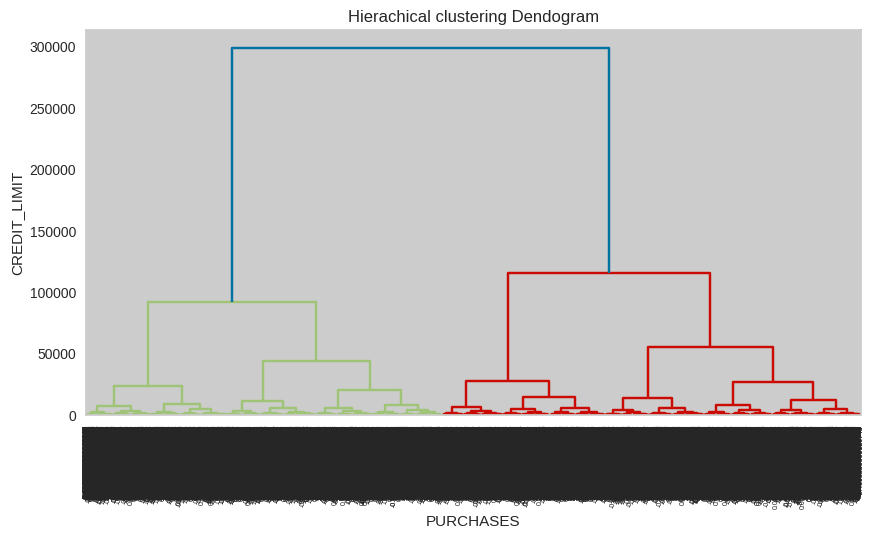

In [ ]:
#plot the dendogram
plt.figure(figsize=(10, 5))
dendogram = sch.dendrogram(linkage_matrix, labels = ds['PURCHASES'].values)
plt.title('Hierachical clustering Dendogram')
plt.xlabel('PURCHASES')
plt.ylabel('CREDIT_LIMIT')
plt.grid(True)
plt.show()

In [ ]:
x = ds[['PURCHASES', 'CREDIT_LIMIT']]
x.head()

,PURCHASES,CREDIT_LIMIT
0,-0.424934,-0.960380
1,-0.469584,0.688601
2,-0.107716,0.826016
3,0.231995,0.826016
4,-0.462095,-0.905414


KeyError: "['ClusterInterprete', 'Cluster'] not found in axis"

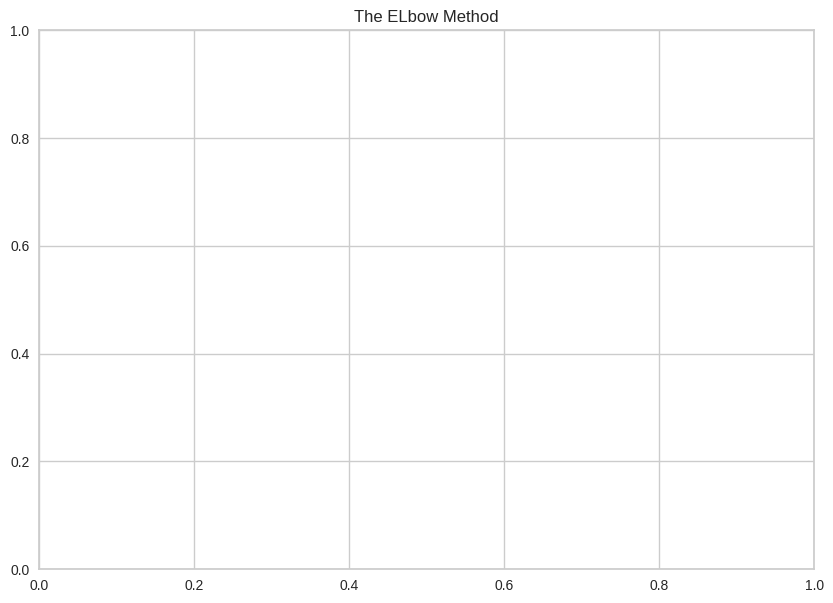

In [ ]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
#Instatiate the clustering model and viualizer
km = KMeans(random_state = 42) # Makes sure results are reproducible. (so every time you run it, you'll get the same clustering)

Visualizer = KElbowVisualizer(km, k=(2, 10)) # tries multiple values of k and shows how well the model fits.test values of k starting from 2 up to 10 clusters

plt.figure(figsize=(10, 7))
plt.title('The ELbow Method')
Visualizer.fit(X.drop(columns=['ClusterInterprete', 'Cluster']))  # fit the data to the visualizer
Visualizer.show()  #finalize and render the figure

In [ ]:
#we initialize the kmeans
from sklearn.cluster import KMeans
k_model = KMeans(n_clusters= 4,       #--This tells K-Means to create 5 clusters in your dataset.Basically, the algorithm will try to group your data into 5 distinct groups based on similarity.
                 init = 'k-means++',    #This is the initialization method for picking the starting cluster centers.
                 n_init= 10,    #This means it will run the algorithm 10 times with different initial centers and keep the best result (the one with lowest error/inertia).
                 max_iter= 100)   #This sets the maximum number of iterations for one run of K-Means.
                                  #K-Means repeats the process:Assign points to nearest cluster. Recompute cluster centers
k_model

KMeans(max_iter=100, n_clusters=4, n_init=10)

In [ ]:
pred_cluster = k_model.fit_predict(x)
x['Cluster'] = pred_cluster
x.head()

/tmp/ipython-input-3533976884.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['Cluster'] = pred_cluster


,PURCHASES,CREDIT_LIMIT,Cluster
0,-0.424934,-0.960380,1
1,-0.469584,0.688601,0
2,-0.107716,0.826016,0
3,0.231995,0.826016,0
4,-0.462095,-0.905414,1


/tmp/ipython-input-3902651996.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['ClusterInterprete'] = x.Cluster.map({0: 'LowPurh_LowCredLimit',


,CUST_ID,BALANCE_FREQUENCY,PURCHASES,PAYMENTS,CREDIT_LIMIT
0,0,-0.249881,-0.424934,-0.529026,-0.960380
1,1,0.134049,-0.469584,0.818546,0.688601
2,2,0.517980,-0.107716,-0.383857,0.826016
3,3,-1.017743,0.231995,-0.598733,0.826016
4,4,0.517980,-0.462095,-0.364421,-0.905414


/tmp/ipython-input-3902651996.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.countplot(x = x.ClusterInterprete, palette = 'Set2')


Text(0.5, 1.0, 'Cluster Class By Average Purchase')

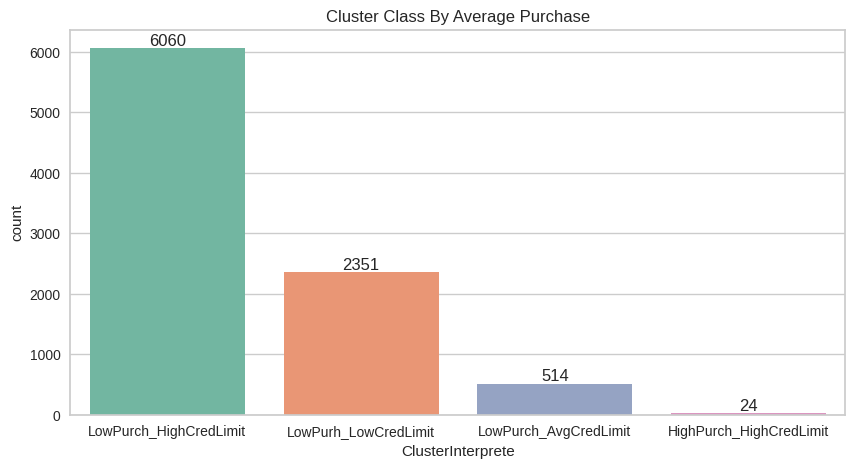

In [ ]:
x['ClusterInterprete'] = x.Cluster.map({0: 'LowPurh_LowCredLimit',
                                        1: 'LowPurch_HighCredLimit',
                                        2: 'LowPurch_AvgCredLimit',
                                        3: 'HighPurch_HighCredLimit'
                                        })

display(X.head())


import seaborn as sns
plt.figure(figsize = (10, 5))
fig = sns.countplot(x = x.ClusterInterprete, palette = 'Set2')
for i in fig.containers:
  fig.bar_label(i)

plt.title('Cluster Class By Average Purchase')

In [ ]:
#K-Best Value
Sum_of_Squared_distances = []
K  = range(1, 15)
for k in K:
  Km = KMeans(n_clusters = k, n_init=10, random_state=42) # Corrected keyword argument
  # Drop 'ClusterInterprete' and 'Cluster' columns before fitting
  Km.fit(ds.drop(columns=['CUST_ID'])) # Fit the model
  Sum_of_Squared_distances.append(Km.inertia_)
Sum_of_Squared_distances

[44744.99999999978,
 34460.22704417404,
 27459.7990410342,
 22256.50346598181,
 18425.701449918557,
 15900.069022637319,
 13765.357713530913,
 12896.615742518634,
 11885.247449868046,
 11105.528842177438,
 10356.267238976496,
 9711.240725330124,
 9254.073479823759,
 8826.207080067597]

The Result shows that the variables are closely clustered together